The following package contains the code necessary to produce visualizations in my MA thesis mapping ideological resonance in QAnon's global diffusion. It contains three main sections:
- **Setup**: Load packages, custom functions, and data.
- **3) Data & Methods**: Code necessary to produce plots in section 3 (Data & Methods).
- **4) Results**: Code necessary to produce plots in section 4 (Results).

Run the setup section first before moving on to any particular table or visualization you are interested in reproducing.

# Setup
## Packages

In [77]:
import importlib
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# analysis_util.py is in the modules subfolder
# Assumes notebook is run from ideological_resonance_thesis/ directory
_modules_path = os.path.join(os.getcwd(), "modules")
if _modules_path not in sys.path:
    sys.path.insert(0, _modules_path)
import analysis_util
importlib.reload(analysis_util)
from analysis_util import filter_top_actions, create_actor_action_matrix, visualize_pca_matrix, add_traces_and_axes, analyze_pca_components, neat_pca_viz


## Load Data

In [78]:
data_dir = os.path.join(os.getcwd(), 'data')

In [79]:
# Load the English motifs with stopwords removed
motifs_en_filtered = pd.read_csv(os.path.join(data_dir, 'motifs_en_filtered.csv'))
motifs_en_filtered['date'] = pd.to_datetime(motifs_en_filtered['date'])

In [80]:
# Load the German motifs with stopwords removed
motifs_de_filtered = pd.read_csv(os.path.join(data_dir, 'motifs_de_filtered.csv'))
motifs_de_filtered['date'] = pd.to_datetime(motifs_de_filtered['date'])

In [81]:
# For PCA, filter for all actors and actions in 0.2-10th percentile (English motifs)
en_actionrange = filter_top_actions(
    motifs_en_filtered,
    actors=('pct', 0, 100),
    actions=('pct', 0.2, 10)
)
print(f"\nFiltered to specified actor and action ranges: {len(en_actionrange):,} rows")

Filtered to 119 actors (pct mode, 0-100)
Filtered to 762 actions (pct mode, 0.2-10)

Filtered to specified actor and action ranges: 1,001,786 rows


In [82]:
# For PCA, filter for all actors and actions in 0.2-10th percentile (German motifs)
de_actionrange = filter_top_actions(
    motifs_de_filtered,
    actors=('pct', 0, 100),
    actions=('pct', 0.2, 10)
)
print(f"\nFiltered to specified actor and action ranges: {len(de_actionrange):,} rows")

Filtered to 125 actors (pct mode, 0-100)
Filtered to 1367 actions (pct mode, 0.2-10)

Filtered to specified actor and action ranges: 832,335 rows


# 3) Data & Methods (Plots)

In [7]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Helper function to compute cumulative stats for a motif DataFrame
def compute_cumulative_stats(motifs_filtered):
    action_counts = motifs_filtered.action.value_counts()
    total_rows = len(motifs_filtered)
    total_unique = len(action_counts)
    cumulative_stats = pd.DataFrame({
        'unique_actions_pct': [(i+1)/total_unique * 100 for i in range(total_unique)],
        'cumulative_rows': action_counts.cumsum().values,
    })
    cumulative_stats['rows_covered_pct'] = (cumulative_stats.cumulative_rows / total_rows * 100).round(2)
    cumulative_stats['unique_actions'] = [(i+1) for i in range(total_unique)]
    return cumulative_stats, action_counts, total_rows

# Prepare data for English and German motifs
lang_data = [
    ('English', motifs_en_filtered),
    ('German', motifs_de_filtered)
]

cumulative_stats_list = []
action_counts_list = []
total_rows_list = []

for lang, df in lang_data:
    stats, counts, total = compute_cumulative_stats(df)
    cumulative_stats_list.append(stats)
    action_counts_list.append(counts)
    total_rows_list.append(total)

# Plotting: 1x2 subplots with plotly, A4 width (1170px at 100dpi)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f"{lang}" for lang, _ in lang_data],
    shared_yaxes=True,
    horizontal_spacing=0.07
)

# Add slight buffer to left (x) and top (y) of axes
x_buffer = 3  # percent
y_buffer = 3  # percent
x_min, x_max = 0 - x_buffer, 100
y_min, y_max = 0, 100 + y_buffer

x_ticks = [0, 25, 50, 75, 100]

for i, (lang, stats) in enumerate(zip(['English', 'German'], cumulative_stats_list)):
    fig.add_trace(
        go.Scatter(
            x=stats['unique_actions_pct'],
            y=stats['rows_covered_pct'],
            mode='lines+markers',
            marker=dict(size=4),
            line=dict(width=2),
            customdata=stats[['unique_actions', 'cumulative_rows']],
            hovertemplate=
                '<b>Unique Actions</b>: %{customdata[0]:,.0f} (%{x:.1f}%)<br>' +
                '<b>Rows Covered</b>: %{customdata[1]:,.0f} (%{y:.1f}%)<extra></extra>',
            name=lang
        ),
        row=1, col=i+1
    )
    fig.update_xaxes(
        title_text='Percentage of Unique Actions',
        range=[x_min, x_max],
        tickfont=dict(size=11),
        tickvals=x_ticks,
        row=1, col=i+1
    )
    if i == 0:
        fig.update_yaxes(
            title_text='Percentage of Total Motifs Covered',
            range=[y_min, y_max],
            tickfont=dict(size=11),
            row=1, col=1
        )
    else:
        fig.update_yaxes(
            range=[y_min, y_max],
            tickfont=dict(size=11),
            row=1, col=i+1
        )

# Set axis title font globally via layout
fig.update_layout(
    title_text='Coverage of Motifs by Unique Actions (Excluding Stop Words)',
    title_x=0.5,
    showlegend=False,
    width=1170,  # A4 width in pixels at 100 dpi
    height=400,
    margin=dict(t=70, b=40, l=80, r=30),  # increased top and left margins for buffer
    hovermode='x unified',
    font=dict(size=12),
    xaxis_title_font=dict(size=12),
    yaxis_title_font=dict(size=12)
)

fig.show()

# Display top 10 most frequent actions for English and German only
for lang, action_counts, total_rows in zip(['English', 'German'], action_counts_list, total_rows_list):
    print(f"\nTop 10 most frequent actions in {lang} (excluding stop words):")
    top_10 = action_counts.head(10)
    for action, count in top_10.items():
        pct = round((count/total_rows * 100), 2)
        print(f"{action}: {count:,} rows ({pct}%)")


Top 10 most frequent actions in English (excluding stop words):
win: 36,377 rows (2.55%)
know: 35,379 rows (2.48%)
want: 26,763 rows (1.88%)
work: 23,823 rows (1.67%)
tell: 23,509 rows (1.65%)
come: 20,623 rows (1.45%)
stand: 20,102 rows (1.41%)
try: 20,080 rows (1.41%)
use: 20,075 rows (1.41%)
ask: 19,636 rows (1.38%)

Top 10 most frequent actions in German (excluding stop words):
geben: 30,080 rows (2.44%)
gewinnen: 20,758 rows (1.68%)
sprechen: 17,736 rows (1.44%)
erklären: 14,121 rows (1.14%)
stellen: 12,847 rows (1.04%)
fordern: 12,514 rows (1.01%)
stehen: 12,204 rows (0.99%)
warnen: 11,834 rows (0.96%)
halten: 11,111 rows (0.9%)
sehen: 10,945 rows (0.89%)


# 4) Results (Tables and Plots)
## 4.1) Comparing Counts
### Table: Top Entities

In [8]:
# Load Qanon NER
ner_df = pd.read_csv(os.path.join(data_dir, 'qanon_ner.csv'))
ner_df['lang_det'] = ner_df['lang_det'].astype('category')

# Load media NER
media_df = pd.read_csv(os.path.join(data_dir, 'media_ner.csv'))

/scratch/local/jobs/46647735/ipykernel_537103/3900455043.py:6: DtypeWarning:

Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.



In [9]:
# Entity table
def get_ranked_entities(df, entity_col='entity_canonical', filter_col=None, filter_val=None, n=10):
    """Get top n entities with their percentages for a corpus"""
    if filter_col and filter_val:
        df = df[df[filter_col] == filter_val]
    mask = df[entity_col].notna() & ~df[entity_col].str.match(r'^[^\w]+$', na=False)
    df = df[mask]
    dist = df[entity_col].value_counts(normalize=True)
    return [(entity, f"{pct*100:.2f}%") for entity, pct in dist.nlargest(n).items()]


filtered_rankings = {
    'Media': get_ranked_entities(media_df, entity_col='entity_canonical', n=10),
    'All Conspiracy': get_ranked_entities(ner_df, entity_col='entity_canonical', n=10),
    'EN Conspiracy': get_ranked_entities(ner_df[ner_df['lang_det'] == 'en'], entity_col='entity_canonical', n=10),
    'DE Conspiracy': get_ranked_entities(ner_df[ner_df['lang_det'] == 'de'], entity_col='entity_canonical', n=10),
}

filtered_table = pd.DataFrame(index=range(1, 11))
for corpus, rankings in filtered_rankings.items():
    filtered_table[corpus] = [f"{entity} ({pct})" for entity, pct in rankings]

print("\nRanked entities with percentages by corpus (filtered data, top 10, no Italian):")
pd.set_option('display.max_colwidth', None)
print(filtered_table.to_string())
pd.reset_option('display.max_colwidth')


Ranked entities with percentages by corpus (filtered data, top 10, no Italian):
                                      Media                           All Conspiracy                            EN Conspiracy                      DE Conspiracy
1                     Donald Trump (26.16%)                    Donald Trump (16.29%)                    Donald Trump (17.46%)              Donald Trump (14.74%)
2                          Fox News (8.14%)                              God (9.96%)                             God (14.10%)                  Joe Biden (5.64%)
3                         Joe Biden (8.11%)                        Joe Biden (7.03%)                        Joe Biden (8.08%)                        God (4.44%)
4                The New York Times (5.02%)                           Pfizer (3.10%)                     Jesus Christ (4.08%)             European Union (4.36%)
5                      Barack Obama (4.62%)                          Twitter (3.05%)                           Pfi

### Plot: Top QAnon Entities (EN only)

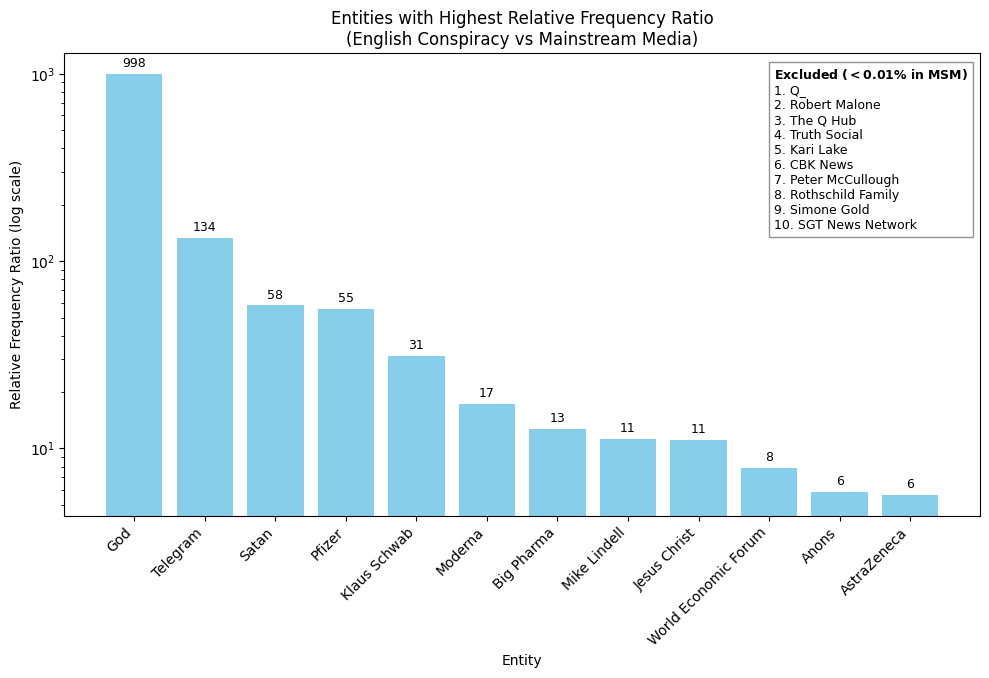

In [10]:
# Entity plot
def get_entity_stats(df, entity_col='entity_canonical'):
    """Get entity counts and frequencies"""
    counts = df[entity_col].value_counts()
    freqs = df[entity_col].value_counts(normalize=True)
    return pd.DataFrame({'count': counts, 'freq': freqs})


# Get English-only, non-DE/IT media stats
media_stats_en = get_entity_stats(
    media_df[~media_df['ner_group'].str.endswith(('_it', '_de'), na=False)]
)

# Get English-only, non-DE/IT conspiracy stats
consp_en_df = ner_df[
    (ner_df['lang_det'] == 'en')
    & ~ner_df['ner_group'].str.endswith(('_it', '_de'), na=False)
]
consp_stats_en = get_entity_stats(consp_en_df)

# Combine stats
combined = pd.DataFrame({
    'media_count': media_stats_en['count'],
    'media_freq': media_stats_en['freq'],
    'consp_count': consp_stats_en['count'],
    'consp_freq': consp_stats_en['freq']
}).fillna(0)

combined['ratio'] = combined['consp_freq'] / (combined['media_freq'] + 1e-10)

# Filter: only entities with at least 0.01% in media, then take top 12 by ratio
filtered = combined[
    (combined['media_freq'] >= 0.0001)
].sort_values('ratio', ascending=False).head(12)

# Prepare excluded entities: those with <0.01% in MSM, ranked by conspiracy freq, top 10
excluded = combined[
    (combined['media_freq'] < 0.0001) & (combined['consp_count'] > 0)
].sort_values('consp_count', ascending=False).head(10)
excluded_names = excluded.index.tolist()

# Barplot
entities = filtered.index.tolist()
ratios = filtered['ratio'].values

plt.figure(figsize=(max(10, len(entities) * 0.7), 6))
bars = plt.bar(range(len(entities)), ratios, color='skyblue', log=True)

plt.xticks(range(len(entities)), entities, rotation=45, ha='right', fontsize=10)
plt.ylabel('Relative Frequency Ratio (log scale)')
plt.xlabel('Entity')
plt.title('Entities with Highest Relative Frequency Ratio\n(English Conspiracy vs Mainstream Media)')

plt.tight_layout()
plt.subplots_adjust(top=1.05)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.05,
        f"{ratios[i]:.0f}",
        ha='center', va='bottom', fontsize=9, rotation=0
    )

if len(excluded_names) > 0:
    box_lines = [f"{i+1}. {name}" for i, name in enumerate(excluded_names)]
    box_text = r"$\bf{Excluded\ (<0.01\%\ in\ MSM)}$" + "\n" + "\n".join(box_lines)
    plt.gca().text(
        0.775, 0.97, box_text,
        transform=plt.gca().transAxes,
        fontsize=9,
        va='top', ha='left',
        bbox=dict(boxstyle='square,pad=0.4', facecolor='white', alpha=0.85, edgecolor='gray')
    )

plt.show()

### Plot: Top QAnon Motifs (EN only)

In [11]:
# Load media motifs (required for comparison)
motifs_media_filt = pd.read_csv(os.path.join(data_dir, 'motifs_media_filtered.csv'))

In [12]:
def compare_frequencies(min_count=None, min_percentage=None, top_n=None):
    """
    Compare verb frequencies with either minimum count or minimum percentage threshold.
    Returns ratios with most_common_actor for top N results.
    """
    en_counts = motifs_en_filtered['action'].value_counts()
    media_counts = motifs_media_filt['action'].value_counts()

    en_pct = (en_counts / len(motifs_en_filtered)) * 100
    media_pct = (media_counts / len(motifs_media_filt)) * 100

    if min_count is not None:
        common_actions = set(en_counts[en_counts >= min_count].index) & set(
            media_counts[media_counts >= min_count].index
        )
    else:
        common_actions = set(en_pct[en_pct >= min_percentage].index) & set(
            media_pct[media_pct >= min_percentage].index
        )

    ratios = pd.DataFrame({
        'en_count': en_counts[list(common_actions)],
        'media_count': media_counts[list(common_actions)],
        'en_pct': en_pct[list(common_actions)],
        'media_pct': media_pct[list(common_actions)]
    })
    ratios['ratio'] = ratios['en_pct'] / ratios['media_pct']
    ratios = ratios.sort_values('ratio', ascending=False)

    if top_n is not None:
        top_actions = ratios.index[:top_n]
        top_actors = {}
        for action in top_actions:
            en_actor_counts = motifs_en_filtered[motifs_en_filtered['action'] == action]['canonical'].value_counts()
            top_actors[action] = en_actor_counts.index[0] if len(en_actor_counts) > 0 else 'N/A'
        ratios['most_common_actor'] = pd.Series(top_actors)

    return ratios.head(top_n) if top_n else ratios


comp_freq = compare_frequencies(min_percentage=0.01, top_n=250)

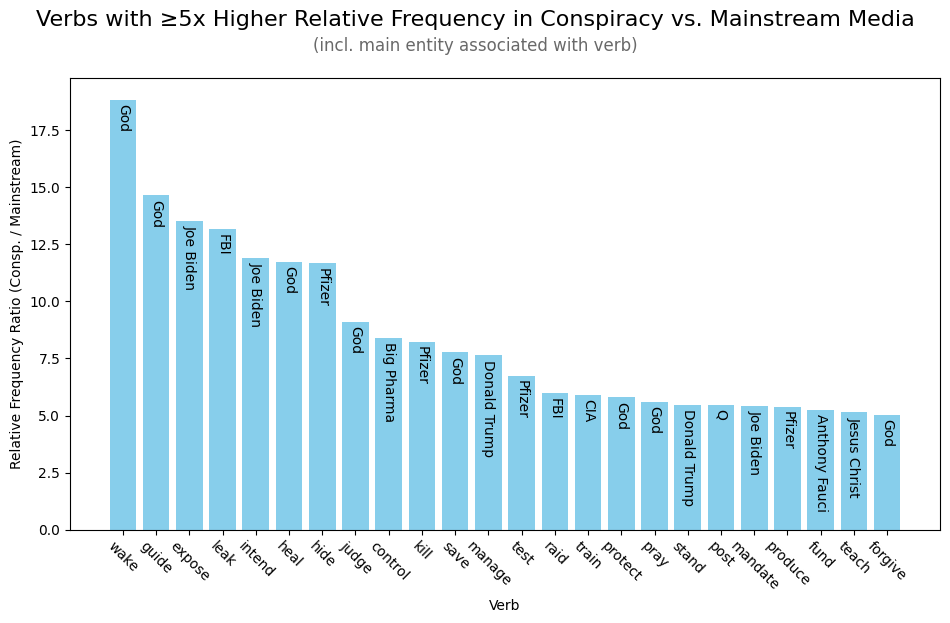

In [13]:
# Bar chart for verbs with ratio > 5
bar_df = comp_freq[comp_freq['ratio'] > 5].copy()
bar_df = bar_df.sort_values('ratio', ascending=False)

if not bar_df.empty:
    fig, ax = plt.subplots(figsize=(max(8, 0.4 * len(bar_df)), 6))
    bars = ax.bar(bar_df.index, bar_df['ratio'], color='skyblue')
    plt.xticks(rotation=-45, ha='center')
    plt.xlabel('Verb')
    plt.ylabel('Relative Frequency Ratio (Consp. / Mainstream)')

    fig.suptitle(
        'Verbs with ≥5x Higher Relative Frequency in Conspiracy vs. Mainstream Media',
        fontsize=16,
        y=1.03
    )
    fig.text(
        0.5, 0.97,
        '(incl. main entity associated with verb)',
        ha='center',
        va='center',
        fontsize=12,
        color='dimgray'
    )
    plt.subplots_adjust(top=0.86)

    for idx, (verb, row) in enumerate(bar_df.iterrows()):
        actor = row['most_common_actor'] if 'most_common_actor' in row else 'N/A'
        if actor == "Federal Bureau of Investigation":
            actor = "FBI"
        elif actor == "Central Intelligence Agency":
            actor = "CIA"
        ax.text(
            idx,
            row['ratio'] - (0.01 * bar_df['ratio'].max()),
            actor,
            ha='center',
            va='top',
            rotation=-90,
            fontsize=10,
            color='black'
        )

    plt.tight_layout()
    plt.show()
else:
    print("No verbs found with ratio > 5 for the current threshold.")

## 4.2-4.3) PCA
### Regular PCA

The code below produces the successive PCA visualizations in sections 4.2 to 4.3 from English/German filtered motifs. At the heart of the visualizations lie a set of helper functions for filtering the range of included actors/motifs, creating an actor-action matrix from the generated motifs, and performing/visualizing the PCA analysis. For more details on these functions, readers are referred to [`modules/pca_util.py`](modules/pca_util.py). 

The core approach repeated across these code blocks is as follows:
- Exclude motifs associated with irrelevant categories of actors
- Select the actors to visualize on the plot
- Add annotations describing verbs and themes
- Generate the actor-action matrix; reduce to two dimension with PCA
- Update figure layout and show visualize

Additionally, each figure contains an optional block of code that can be run to display the loading of verbs onto each PCA pole and the placement of verbs on the PCA (placement calculated using verb loadings).

#### EN PCA, All Entities

In [62]:
# Create filter mask to exclude DE and IT actors
filter_mask = ~en_actionrange['category'].str.endswith(('_it', '_de'))

viz_entities = [
    "Alex Jones",
    "Amazon",
    "Assange Wikileaks",
    "Bill Gates",
    "Central Intelligence Agency",
    "Centers for Disease Control and Prevention",
    "Deep State",
    "Donald Trump",
    "Epoch Times",
    "Federal Bureau of Investigation",
    "Food and Drug Administration",
    "Fox News",
    "God",
    "Instagram",
    "Jesus Christ",
    "Joe Biden",
    "Linn Wood",
    "Lucifer",
    "Moderna",
    "Patriots",
    "Q",
    "Robert Kennedy Jr.",
    "Rothschild Family",
    "Satan",
    "The New York Times",
    "World Health Organization",
]

area_annotations = [
    {
        "pos": (0.2, 0.5),
        "title": ["Religious Actions", "spiritual_good"],
        "verbs": ["forgive", "guide", "judge", "love", "ordain", "prophesy", "purify", "redeem", "resurrect", "shall"],
    },
    {
        "pos": (-0.5, 0.0675),
        "title": ["Epistemic Conflict", "mainstreammedia_us"],
        "verbs": ["ban", "block", "censor", "comment", "disclose", "limit", "note", "publish", "report", "suppress"],
    },
    {
        "pos": (0.35, -0.05),
        "title": ["Political Conflict", "donald_trump"],
        "verbs": ["attempt", "cheat", "dismantle", "execute", "instal", "orchestrate", "play", "press", "steal", "wage"],
    },
]

axis_labels = {
    "top_lab": ("Religious"),
    "bot_lab": ("Mundane: <br>Political"),
    "left_lab": ("Mundane: <br>Epistemic"),
    "right_lab": ("Religious"),
}

pca, transformed, features, matrix, fig = neat_pca_viz(create_actor_action_matrix(en_actionrange, (
        'action', 'canonical', 'category'), category_actors=False,  filter_mask=filter_mask, normalize='rows'),
    n_components=2, scale_to_unit=True, logscale=True,
    viz_entities=viz_entities, area_annotations=area_annotations, axis_annotations=axis_labels)

fig.update_layout(
    width=1500,  # Not too wide
    height=1500, 
    showlegend=True,
    template="plotly_white",
    margin=dict(l=60, r=60, t=60, b=60)
)

fig.show()

In [45]:
# OPTIONAL: Show plot with verbs only and verb loadings on PCA components (used to generate custom plot annotations)
pca, transformed, features, matrix, fig = visualize_pca_matrix(create_actor_action_matrix(en_actionrange, (
        'action', 'canonical', 'category'), category_actors=False,  filter_mask=filter_mask, normalize='rows'),
    n_components=2, actors=False, actions=True, scale_to_unit=True, logscale=True) # Detail: actors=False, actions=True

fig.update_layout(
    width=1000,
    height=1000, 
    showlegend=True,
    template="plotly_white",
    margin=dict(l=60, r=60, t=60, b=60)
)

fig.show()

analyze_pca_components(
    pca, # Fitted PCA object
    features, # List of column names
    scree=False, # Show scree plot
    axes_words=(True, 2), # Show words for top 3 components
)


PC1 (5.8% variance)
| Negative Pole | Loading | Loading | Positive Pole |
|---------------|----------|----------|---------------|
| update        |   -0.036 |    0.125 | love          |
| comment       |   -0.032 |    0.116 | command       |
| disclose      |   -0.032 |    0.115 | choose        |
| suppress      |   -0.030 |    0.115 | guide         |
| estimate      |   -0.029 |    0.115 | prophesy      |
| admit         |   -0.028 |    0.114 | reign         |
| develop       |   -0.027 |    0.114 | rebuke        |
| ban           |   -0.027 |    0.113 | forgive       |
| vaccinate     |   -0.027 |    0.112 | hath          |
| report        |   -0.026 |    0.112 | forsake       |
| censor        |   -0.026 |    0.110 | comfort       |
| block         |   -0.026 |    0.110 | defeat        |
| note          |   -0.026 |    0.110 | shall         |
| produce       |   -0.025 |    0.109 | overcome      |
| limit         |   -0.025 |    0.108 | dwell         |
| add           |   -0.025 | 

#### EN PCA, Excluding Spiritual Entities

In [70]:
# Create filter mask to exclude DE and IT actors as well as religious entities
filter_mask = ~en_actionrange['category'].str.endswith(('_it', '_de', 'good', 'bad'))

viz_entities = [
    "Alex Jones",
    "Amazon",
    "Anthony Fauci",
    "Assange Wikileaks",
    "Barack Obama",
    "Centers for Disease Control and Prevention",
    "Central Intelligence Agency",
    "Deep State",
    "Department of Justice",
    "Donald Trump",
    "Federal Bureau of Investigation",
    "Food and Drug Administration",
    "Fox News",
    "George Bush",
    "George Soros",
    "Ghislaine Maxwell",
    "Google",
    "Instagram",
    "Joe Biden",
    "Linn Wood",
    "Michael Flynn",
    "Moderna",
    "NATO",
    "Patriots",
    "Q",
    "Robert Kennedy Jr.",
    "Robert Malone",
    "The Q Hub",
    "Truth Social",
    "World Health Organization",
]

area_annotations = [
    {
        "pos": (-0.75, 0.8),  # Top left quadrant (-X, +Y)
        "title": ["Epistemic Institutions", "tech"],
        "verbs": sorted(["censor", "ban", "track", "suppress", "manufacture"]),
    },
    {
        "pos": (0.7, 0.85),  # Top right quadrant (+X, +Y)
        "title": ["Political Institutions", "nwo"],
        "verbs": sorted(["dismantle", "grab", "steal", "deploy", "enforce"]),
    },
    {
        "pos": (0.55, -0.75),  # Bottom right quadrant (+X, -Y)
        "title": ["Political Individuals", "qanon_pro"],
        "verbs": sorted(["smile", "blast", "shout", "feel", "nominate"]),
    },
    {
        "pos": (-0.7, -0.55),  # Bottom left quadrant (-X, -Y)
        "title": ["Epistemic Individuals", "antivax_us"],
        "verbs": sorted(["point", "explain", "reveal", "highlight", "talk"]),
    },
]

axis_labels = {
    "top_lab": ("Institutional",),
    "bot_lab": ("Individual",),
    "left_lab": ("Epistemic",),
    "right_lab": ("Political",),
}

pca, transformed, features, matrix, fig = neat_pca_viz(create_actor_action_matrix(en_actionrange, (
        'action', 'canonical', 'category'), category_actors=False,  filter_mask=filter_mask, normalize='rows'),
    n_components=2, scale_to_unit=True, logscale=False,
    viz_entities=viz_entities, area_annotations=area_annotations, axis_annotations=axis_labels)

fig.update_layout(
    width=1500,  # Not too wide
    height=1500, 
    showlegend=True,
    template="plotly_white",
    margin=dict(l=60, r=60, t=60, b=60)
)

fig.show()

In [47]:
# OPTIONAL: Show plot with verbs only and verb loadings on PCA components (used to generate custom plot annotations)
pca, transformed, features, matrix, fig = visualize_pca_matrix(create_actor_action_matrix(en_actionrange, (
        'action', 'canonical', 'category'), category_actors=False,  filter_mask=filter_mask, normalize='rows'),
    n_components=2, actors=False, actions=True, scale_to_unit=True, logscale=False) # Detail: actors=False, actions=True

fig.update_layout(
    width=1000,
    height=1000, 
    showlegend=True,
    template="plotly_white",
    margin=dict(l=60, r=60, t=60, b=60)
)

fig.show()

analyze_pca_components(
    pca, # Fitted PCA object
    features, # List of column names
    scree=False, # Show scree plot
    axes_words=(True, 2), # Show words for top 3 components
)


PC1 (4.9% variance)
| Negative Pole | Loading | Loading | Positive Pole |
|---------------|----------|----------|---------------|
| censor        |   -0.044 |    0.108 | hold          |
| update        |   -0.043 |    0.103 | look          |
| report        |   -0.040 |    0.099 | set           |
| reveal        |   -0.040 |    0.098 | steal         |
| start         |   -0.040 |    0.091 | execute       |
| ban           |   -0.039 |    0.089 | tie           |
| delete        |   -0.038 |    0.087 | press         |
| explain       |   -0.037 |    0.086 | orchestrate   |
| limit         |   -0.037 |    0.084 | cross         |
| interview     |   -0.036 |    0.084 | instal        |
| disclose      |   -0.036 |    0.084 | cry           |
| share         |   -0.035 |    0.083 | care          |
| mark          |   -0.034 |    0.083 | leave         |
| produce       |   -0.034 |    0.083 | fuck          |
| review        |   -0.034 |    0.083 | meet          |
| suppress      |   -0.033 | 

#### GE PCA, all Entities

In [72]:
# Create filter mask to exclude relevant US and IT actors
filter_mask = ~de_actionrange['category'].str.endswith(
    (
        '_it', "alt_politics_us", "security_us", "biomed_us", "mainstreammedia_us", "altmedia_us", "antivax_us"
    )
)

viz_entities = [
    "Amazon",
    "Angela Merkel",
    "Annalena Baerbock",
    "ARD",
    "AstraZeneca",
    "Barack Obama",
    "Bill Gates",
    "Bodo Schiffmann",
    "Bundeswehr",
    "Christian Drosten",
    "Deep State",
    "Die Welt",
    "Donald Trump",
    "European Union",
    "Freie Medien",
    "George Bush",
    "God",
    "Google",
    "Hans-Georg Maaßen",
    "Jens Spahn",
    "Jesus Christ",
    "Joe Biden",
    "Karl Lauterbach",
    "Michael Ballweg",
    "Moderna",
    "Nancy Pelosi",
    "NATO",
    "Olaf Scholz",
    "Patriots",
    "Paul-Ehrlich-Institut",
    "Q",
    "Robert Koch-Institut",
    "Sucharit Bhakdi",
    "Verfassungsschutz",
    "World Economic Forum",
    "World Health Organization",
    "ZDF",
]

area_annotations = [
    {
        "pos": (-0.6, 0.7),  # Top left quadrant (-X, +Y)
        "title": ["Epistemic Institutions", "tech"],
        "verbs": ["ban", "censor", "manufacture", "suppress", "track"],
    },
    {
        "pos": (0.6, 0.7),  # Top right quadrant (+X, +Y)
        "title": ["Political Institutions", "nwo"],
        "verbs": ["deploy", "dismantle", "enforce", "grab", "steal"],
    },
    {
        "pos": (0.65, -0.8),  # Bottom right quadrant (+X, -Y)
        "title": ["Political Individuals", "qanon_pro"],
        "verbs": ["blast", "feel", "nominate", "shout", "smile"],
    },
    {
        "pos": (-0.7, -0.65),  # Bottom left quadrant (-X, -Y)
        "title": ["Epistemic Individuals", "antivax_de"],
        "verbs": ["explain", "highlight", "point", "reveal", "talk"],
    },
]

axis_labels = {
    "top_lab": ("Institutional",),
    "bot_lab": ("Individual",),
    "left_lab": ("Epistemic",),
    "right_lab": ("Political",),
}

pca, transformed, features, matrix, fig = neat_pca_viz(create_actor_action_matrix(de_actionrange, (
        'action', 'canonical', 'category'), category_actors=False,  filter_mask=filter_mask, normalize='rows'),
    n_components=2, scale_to_unit=True, logscale=False,
    viz_entities=viz_entities, area_annotations=area_annotations, axis_annotations=axis_labels)

fig.update_layout(
    width=1500,  # Not too wide
    height=1500, 
    showlegend=True,
    template="plotly_white",
    margin=dict(l=60, r=60, t=60, b=60)
)

fig.show()

In [49]:
# OPTIONAL: Show plot with verbs only and verb loadings on PCA components (used to generate custom plot annotations)
pca, transformed, features, matrix, fig = visualize_pca_matrix(create_actor_action_matrix(de_actionrange, (
        'action', 'canonical', 'category'), category_actors=False,  filter_mask=filter_mask, normalize='rows'),
    n_components=2, actors=False, actions=True, scale_to_unit=True, logscale=False) # Detail: actors=False, actions=True

fig.update_layout(
    width=1000,
    height=1000, 
    showlegend=True,
    template="plotly_white",
    margin=dict(l=60, r=60, t=60, b=60)
)

fig.show()

analyze_pca_components(
    pca, # Fitted PCA object
    features, # List of column names
    scree=False, # Show scree plot
    axes_words=(True, 2), # Show words for top 3 components
)


PC1 (3.5% variance)
| Negative Pole | Loading | Loading | Positive Pole |
|---------------|----------|----------|---------------|
| finden        |   -0.040 |    0.081 | vermeiden     |
| analysieren   |   -0.038 |    0.079 | fortsetzen    |
| entwerfen     |   -0.036 |    0.079 | verschwenden  |
| klären        |   -0.034 |    0.078 | zündeln       |
| enthalten     |   -0.033 |    0.077 | erlassen      |
| abonnieren    |   -0.032 |    0.076 | rennen        |
| recherchieren |   -0.032 |    0.076 | vorbereiten   |
| verschweigen  |   -0.032 |    0.076 | verlängern    |
| beschreiben   |   -0.030 |    0.075 | heraufbeschwören |
| erheben       |   -0.029 |    0.074 | beschleunigen |
| herausbringen |   -0.029 |    0.071 | senken        |
| widmen        |   -0.029 |    0.070 | zerschlagen   |
| listen        |   -0.029 |    0.070 | auflegen      |
| verweigern    |   -0.027 |    0.068 | erzwingen     |
| wagen         |   -0.027 |    0.067 | wählen        |
| angeben       |   -0.027

#### GE PCA, Excluding Spiritual Entities (Appendix D)

In [50]:
# Create filter mask to exclude religious entities as well as relevant US and IT actors
filter_mask = ~de_actionrange['category'].str.endswith(
    (
        '_it', "alt_politics_us", "security_us", "biomed_us", "mainstreammedia_us", "altmedia_us", "antivax_us", "good", "bad"
    )
)

viz_entities = [
    "Amazon",
    "Angela Merkel",
    "Annalena Baerbock",
    "Anons",
    "Barack Obama",
    "Bill Gates",
    "Bodo Schiffmann",
    "Bundeswehr",
    "Christian Drosten",
    "Deep State",
    "Die Welt",
    "Donald Trump",
    "Freie Medien",
    "George Bush",
    "Google",
    "Hans-Georg Maaßen",
    "Jens Spahn",
    "Joe Biden",
    "Karl Lauterbach",
    "Michael Ballweg",
    "Moderna",
    "NATO",
    "Nancy Pelosi",
    "Olaf Scholz",
    "Patriots",
    "Q",
    "Sucharit Bhakdi",
    "Verfassungsschutz",
    "World Health Organization",
    "ZDF",
    "European Union",
    "AstraZeneca",
]

axis_labels = {
    "top_lab": ("Institutional",),
    "bot_lab": ("Individual",),
    "left_lab": ("Epistemic",),
    "right_lab": ("Political",),
}

pca, transformed, features, matrix, fig = neat_pca_viz(create_actor_action_matrix(de_actionrange, (
        'action', 'canonical', 'category'), category_actors=False,  filter_mask=filter_mask, normalize='rows'),
    n_components=2, scale_to_unit=True, logscale=False,
    viz_entities=viz_entities, axis_annotations=axis_labels)

fig.update_layout(
    width=1500,  # Not too wide
    height=1500, 
    showlegend=True,
    template="plotly_white",
    margin=dict(l=60, r=60, t=60, b=60)
)

fig.show()

In [51]:
# OPTIONAL: Show plot with verbs only and verb loadings on PCA components (used to generate custom plot annotations)
pca, transformed, features, matrix, fig = visualize_pca_matrix(create_actor_action_matrix(de_actionrange, (
        'action', 'canonical', 'category'), category_actors=False,  filter_mask=filter_mask, normalize='rows'),
    n_components=2, actors=False, actions=True, scale_to_unit=True, logscale=False) # Detail: actors=False, actions=True

fig.update_layout(
    width=1000,
    height=1000, 
    showlegend=True,
    template="plotly_white",
    margin=dict(l=60, r=60, t=60, b=60)
)

fig.show()

analyze_pca_components(
    pca, # Fitted PCA object
    features, # List of column names
    scree=False, # Show scree plot
    axes_words=(True, 2), # Show words for top 3 components
)


PC1 (3.8% variance)
| Negative Pole | Loading | Loading | Positive Pole |
|---------------|----------|----------|---------------|
| finden        |   -0.039 |    0.082 | vermeiden     |
| analysieren   |   -0.035 |    0.081 | erlassen      |
| entwerfen     |   -0.034 |    0.080 | besiegen      |
| klären        |   -0.032 |    0.078 | zündeln       |
| enthalten     |   -0.032 |    0.078 | auflegen      |
| abonnieren    |   -0.031 |    0.078 | fortsetzen    |
| recherchieren |   -0.030 |    0.078 | verlängern    |
| verschweigen  |   -0.030 |    0.076 | verschwenden  |
| beschreiben   |   -0.029 |    0.076 | rennen        |
| erheben       |   -0.028 |    0.075 | vorbereiten   |
| herausbringen |   -0.028 |    0.074 | heraufbeschwören |
| widmen        |   -0.028 |    0.073 | abwenden      |
| listen        |   -0.028 |    0.072 | beschleunigen |
| lesen         |   -0.026 |    0.071 | senken        |
| unterstellen  |   -0.026 |    0.071 | zerschlagen   |
| folgen        |   -0.026

### 'Distorted' PCA
#### EN PCA Distorted

In [86]:
# Create filter mask to exclude DE, IT, and religious actors
filter_mask = ~en_actionrange['category'].str.endswith(('_it', '_de', 'good', 'bad'))

viz_entities = [
    "Alex Jones",
    "Barack Obama",
    "Centers for Disease Control and Prevention",
    "Central Intelligence Agency",
    "Deep State",
    "Department of Justice",
    "Donald Trump",
    "Epoch Times",
    "Facebook",
    "Federal Bureau of Investigation",
    "Food and Drug Administration",
    "Fox News",
    "George Bush",
    "George Soros",
    "Ghislaine Maxwell",
    "Hillary Clinton",
    "Instagram",
    "Joe Biden",
    "Michael Flynn",
    "Moderna",
    "Patriots",
    "Pfizer",
    "Q",
    "Robert Kennedy Jr.",
    "Telegram",
    "World Economic Forum",
    "World Health Organization",
]

area_annotations = [
    {
        "pos": (0.5, 0.25),
        "title": ["Trump and Allies", "donald_trump"],
        "verbs": [
            "awaken", "beat", "blast", "defeat", "drain", "endorse", "inspire", "promise", "reveal", "troll"
        ],
    },
    {
        "pos": (-0.4, 0.2),
        "title": ["Epistemic Conflict", "antivax_us"],
        "verbs": [
            "air", "broadcast", "control", "delete", "interview", "obtain", "report", "scrub", "spread", "summarize"
        ],
    },
    {
        "pos": (0.5, -0.15),
        "title": ["Elite Downfall", "elites_us"],
        "verbs": [
            "attempt", "blame", "cheat", "finance", "fuck", "implode", "ruin", "struggle", "surrender", "target"
        ],
    },
]

axis_labels = {
    "top_lab": ("\'Good\'",),
    "bot_lab": ("\'Bad\'",),
    "left_lab": ("Epistemic",),
    "right_lab": ("Political",),
}

# To obtain a distorted PCA plot, setting normalize='both'
pca, transformed, features, matrix, fig = neat_pca_viz(create_actor_action_matrix(en_actionrange, (
        'action', 'canonical', 'category'), category_actors=False,  filter_mask=filter_mask, normalize='both'),
    n_components=2, scale_to_unit=True, logscale=True,
    viz_entities=viz_entities, area_annotations=area_annotations, axis_annotations=axis_labels)

fig.update_layout(
    width=1500,  # Not too wide
    height=1500, 
    showlegend=True,
    template="plotly_white",
    margin=dict(l=60, r=60, t=60, b=60)
)

fig.show()

In [53]:
# OPTIONAL: Show plot with verbs only and verb loadings on PCA components (used to generate custom plot annotations)
pca, transformed, features, matrix, fig = visualize_pca_matrix(create_actor_action_matrix(en_actionrange, (
        'action', 'canonical', 'category'), category_actors=False,  filter_mask=filter_mask, normalize='both'),
    n_components=2, actors=False, actions=True, scale_to_unit=True, logscale=True) # Detail: actors=False, actions=True

fig.update_layout(
    width=1000,
    height=1000, 
    showlegend=True,
    template="plotly_white",
    margin=dict(l=60, r=60, t=60, b=60)
)

fig.show()

analyze_pca_components(
    pca, # Fitted PCA object
    features, # List of column names
    scree=False, # Show scree plot
    axes_words=(True, 2), # Show words for top 3 components
)


PC1 (18.4% variance)
| Negative Pole | Loading | Loading | Positive Pole |
|---------------|----------|----------|---------------|
| broadcast     |   -0.007 |    0.079 | hold          |
| report        |   -0.007 |    0.078 | grab          |
| air           |   -0.007 |    0.078 | leave         |
| spread        |   -0.005 |    0.076 | look          |
| obtain        |   -0.005 |    0.076 | promise       |
| limit         |   -0.005 |    0.076 | beat          |
| censor        |   -0.005 |    0.076 | choose        |
| sentence      |   -0.005 |    0.075 | walk          |
| express       |   -0.004 |    0.074 | defeat        |
| delete        |   -0.004 |    0.073 | push          |
| corruptcontrol |   -0.004 |    0.073 | pardon        |
| patent        |   -0.004 |    0.073 | suppose       |
| interview     |   -0.004 |    0.073 | had-to        |
| tip           |   -0.004 |    0.073 | deliver       |
| summarize     |   -0.004 |    0.072 | congratulate  |
| flood         |   -0.004 

#### GE PCA Distorted

In [ ]:
# Create filter mask to exclude relevant US and IT actors
filter_mask = ~de_actionrange['category'].str.endswith(
    (
        '_it', "alt_politics_us", "security_us", "biomed_us", "mainstreammedia_us", "altmedia_us", "antivax_us"
    )
)

viz_entities = [
    "Amazon",
    "Angela Merkel",
    "Annalena Baerbock",
    "ARD",
    "Barack Obama",
    "Bill Gates",
    "Big Pharma",
    "Bundeswehr",
    "Christian Drosten",
    "Deep State",
    "Die Welt",
    "Donald Trump",
    "European Union",
    "Freie Medien",
    "George Soros",
    "Hillary Clinton",
    "Jeffrey Epstein",
    "Jens Spahn",
    "Jesus Christ",
    "Joe Biden",
    "Markus Söder",
    "Moderna",
    "NATO",
    "Olaf Scholz",
    "Q",
    "Robert Koch-Institut",
    "Robert-Koch-Institut",
    "Sucharit Bhakdi",
    "Verfassungsschutz",
    "World Economic Forum",
    "World Health Organization"
]

area_annotations = [
    {
        "pos": (0.5, 0.25),
        "title": ["Messianic Trump", "donald_trump"],
        "verbs": [
            "conspire", "drain", "govern", "govern", "launch", "mock", "order", "thrwart", "trick", "uncover"
        ],
    },
    {
        "pos": (-0.4, 0.2),
        "title": ["Epistemic Conflict", "antivax_de"],
        "verbs": [
            "analyze", "conceal/hide", "expose", "grasp", "hack", "recommend", "register", "relativize", "report", "speculate"
        ],
    },
    {
        # "pos": (0.6, -0.1),
        "pos": (0.025, -0.3),
        "title": ["Fallen Order", "elites_us"],
        "verbs": [
            "aggravate", "disintegrate", "escalate", "exploit", "fail", "ignite", "occupy", "risk", "terrorize", "weaken"
        ],
    },
]

axis_labels = {
    "top_lab": ("\'Good\'",),
    "bot_lab": ("\'Bad\'",),
    "left_lab": ("Epistemic",),
    "right_lab": ("Political",),
}

# To obtain a distorted PCA plot, setting normalize='both'
pca, transformed, features, matrix, fig = neat_pca_viz(create_actor_action_matrix(de_actionrange, (
        'action', 'canonical', 'category'), category_actors=False,  filter_mask=filter_mask, normalize='both'),
    n_components=2, scale_to_unit=True, logscale=True,
    viz_entities=viz_entities, area_annotations=area_annotations, axis_annotations=axis_labels)

fig.update_layout(
    width=1500,  # Not too wide
    height=1500, 
    showlegend=True,
    template="plotly_white",
    margin=dict(l=60, r=60, t=60, b=60)
)

fig.show()

In [83]:
# OPTIONAL: Show plot with verbs only and verb loadings on PCA components (used to generate custom plot annotations)
pca, transformed, features, matrix, fig = visualize_pca_matrix(create_actor_action_matrix(de_actionrange, (
        'action', 'canonical', 'category'), category_actors=False,  filter_mask=filter_mask, normalize='both'),
    n_components=2, actors=False, actions=True, scale_to_unit=True, logscale=True, translate='de') # Detail: actors=False, actions=True

fig.update_layout(
    width=1000,
    height=1000, 
    showlegend=True,
    template="plotly_white",
    margin=dict(l=60, r=60, t=60, b=60)
)

fig.show()

analyze_pca_components(
    pca, # Fitted PCA object
    features, # List of column names
    scree=False, # Show scree plot
    axes_words=(True, 2), # Show words for top 2 components
)


PC1 (11.9% variance)
| Negative Pole | Loading | Loading | Positive Pole |
|---------------|----------|----------|---------------|
| abonnieren    |   -0.010 |    0.072 | spielen       |
| entwerfen     |   -0.008 |    0.069 | wählen        |
| beitreten     |   -0.008 |    0.068 | erlassen      |
| erstellen     |   -0.008 |    0.067 | wiederholen   |
| analysieren   |   -0.007 |    0.067 | verspotten    |
| spekulieren   |   -0.007 |    0.065 | unterschreiben |
| listen        |   -0.007 |    0.065 | befehligen    |
| fassen        |   -0.006 |    0.065 | annullieren   |
| widmen        |   -0.006 |    0.063 | unterzeichnen |
| hacken        |   -0.006 |    0.063 | auftreten     |
| erfassen      |   -0.006 |    0.062 | loben         |
| grüßen        |   -0.005 |    0.062 | nominieren    |
| ansehen       |   -0.005 |    0.062 | bezeichnen    |
| verschwiegen  |   -0.005 |    0.062 | hinterlassen  |
| darlegen      |   -0.005 |    0.061 | lässt         |
| relativieren  |   -0.005 